In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [3]:
df=pd.read_csv('titanic/train.csv')
print(df.head())
print(df.info())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [6]:
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [7]:
le = LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df['Embarked']=le.fit_transform(df['Embarked'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [8]:
x=df.drop('Survived',axis=1)
y=df['Survived']


In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 7)
(179, 7)
(712,)
(179,)


In [10]:
lr=LogisticRegression()
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
lr_pred=lr.predict(x_test)
print(lr_pred[:10])
print("Classification Report:\n",classification_report(y_test,lr_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,lr_pred))

[0 0 0 1 1 1 1 0 1 1]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Confusion Matrix:
 [[90 15]
 [19 55]]


In [12]:
lr_acc=accuracy_score(y_test,lr_pred)
lr_f1=f1_score(y_test,lr_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("Logistic Regression F1 Score:", lr_f1)

Logistic Regression Accuracy: 0.8100558659217877
Logistic Regression F1 Score: 0.7638888888888888


In [13]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
knn_pred=knn.predict(x_test)
print(knn_pred[:10])
print("Classification Report:\n",classification_report(y_test,knn_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,knn_pred))  

[0 0 0 0 0 1 1 0 1 1]
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.83      0.78       105
           1       0.70      0.57      0.63        74

    accuracy                           0.72       179
   macro avg       0.72      0.70      0.70       179
weighted avg       0.72      0.72      0.71       179

Confusion Matrix:
 [[87 18]
 [32 42]]


In [15]:
knn_acc=accuracy_score(y_test,knn_pred)
knn_f1=f1_score(y_test,knn_pred)    
print("KNN Accuracy:", knn_acc)
print("KNN F1 Score:", knn_f1)

KNN Accuracy: 0.7206703910614525
KNN F1 Score: 0.6268656716417911


In [16]:
ss=StandardScaler()
x_train_scaled=ss.fit_transform(x_train)
x_test_scaled=ss.transform(x_test)

In [17]:
knn_scaled=KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(x_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
knn_sc_pred=knn_scaled.predict(x_test_scaled)
print(knn_sc_pred[:10]) 
print("Classification Report(scaled):\n",classification_report(y_test,knn_sc_pred))
print("Confusion Matrix(scaled):\n",confusion_matrix(y_test,knn_sc_pred))

[0 0 0 1 0 1 1 0 1 1]
Classification Report(scaled):
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix(scaled):
 [[90 15]
 [21 53]]


In [19]:
knn_sc_acc=accuracy_score(y_test,knn_sc_pred)
knn_sc_f1=f1_score(y_test,knn_sc_pred)  
print("KNN Scaled Accuracy:", knn_sc_acc)
print("KNN Scaled F1 Score:", knn_sc_f1)

KNN Scaled Accuracy: 0.7988826815642458
KNN Scaled F1 Score: 0.7464788732394366


In [20]:
knn_comparison = pd.DataFrame({
    'Algorithm': ['KNN', 'KNN Scaled'],
    'Accuracy': [knn_acc, knn_sc_acc],
    'F1 Score': [knn_f1, knn_sc_f1] 
})
print(knn_comparison)

    Algorithm  Accuracy  F1 Score
0         KNN  0.720670  0.626866
1  KNN Scaled  0.798883  0.746479


In [21]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
dt_pred=dt.predict(x_test)
print(dt_pred[:10])
print("Classification Report:\n",classification_report(y_test,dt_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,dt_pred))

[0 1 1 1 1 1 1 0 1 1]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.82       105
           1       0.75      0.76      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179

Confusion Matrix:
 [[86 19]
 [18 56]]


In [23]:
dt_acc=accuracy_score(y_test,dt_pred)
dt_f1=f1_score(y_test,dt_pred)
print("Decision Tree Accuracy:", dt_acc)
print("Decision Tree F1 Score:", dt_f1)

Decision Tree Accuracy: 0.7932960893854749
Decision Tree F1 Score: 0.7516778523489933


In [24]:
rfc=RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
rfc_pred=rfc.predict(x_test)
print(rfc_pred[:10])    
print("Classification Report:\n",classification_report(y_test,rfc_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,rfc_pred))


[0 0 0 1 0 1 1 0 1 1]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Confusion Matrix:
 [[91 14]
 [20 54]]


In [26]:
rfc_acc=accuracy_score(y_test,rfc_pred)
rfc_f1=f1_score(y_test,rfc_pred)
print("Random Forest Accuracy:", rfc_acc)
print("Random Forest F1 Score:", rfc_f1)

Random Forest Accuracy: 0.8100558659217877
Random Forest F1 Score: 0.7605633802816901


In [27]:
results = pd.DataFrame({
    'Algorithm': ['Logistic Regression', 'KNN','KNN_scaled','Decision Tree', 'Random Forest'],
    'Accuracy': [lr_acc, knn_acc, knn_sc_acc, dt_acc, rfc_acc],
    'F1 Score': [lr_f1, knn_f1, knn_sc_f1, dt_f1, rfc_f1]
})

print(results)

             Algorithm  Accuracy  F1 Score
0  Logistic Regression  0.810056  0.763889
1                  KNN  0.720670  0.626866
2           KNN_scaled  0.798883  0.746479
3        Decision Tree  0.793296  0.751678
4        Random Forest  0.810056  0.760563


In [28]:
print("Best Algorithm based on Accuracy:", results.loc[results['Accuracy'].idxmax()]['Algorithm'])
print("Best Algorithm based on F1 Score:", results.loc[results['F1 Score'].idxmax()]['Algorithm'])

Best Algorithm based on Accuracy: Logistic Regression
Best Algorithm based on F1 Score: Logistic Regression


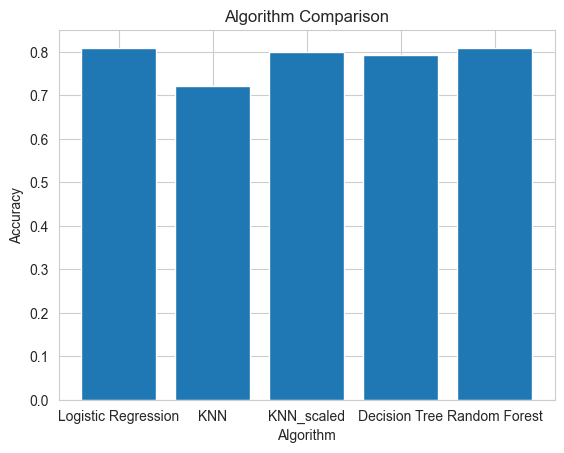

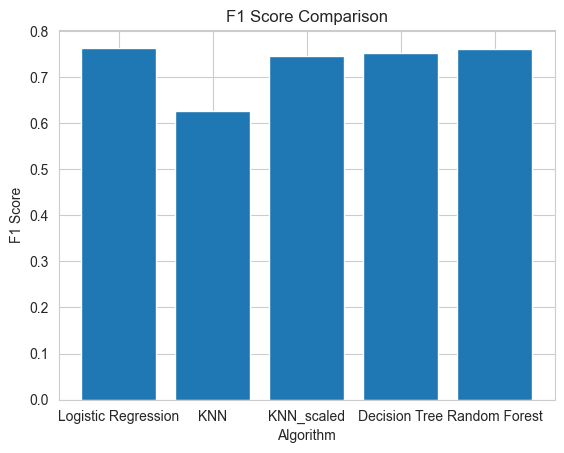

In [29]:
plt.bar(results['Algorithm'], results['Accuracy'])
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")

plt.title("Algorithm Comparison")

plt.show()

plt.bar(results['Algorithm'], results['F1 Score'])
plt.xlabel("Algorithm")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")
plt.show()

# Exploratory Data Analysis (EDA)

C:\Users\LP\AppData\Local\Temp\ipykernel_14840\1861895332.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=gender_labels,palette={'Did Not Survive': 'steelblue', 'Survived': 'orange'})


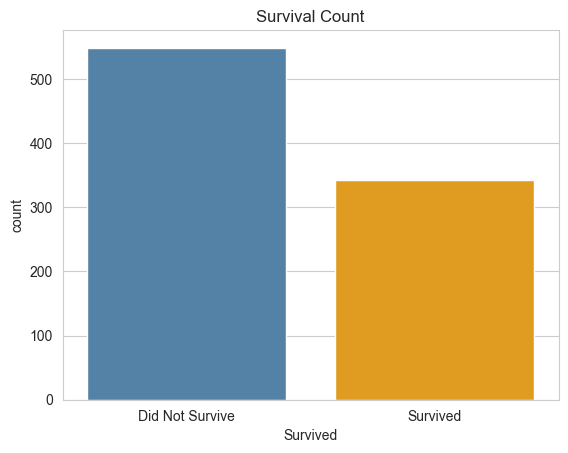

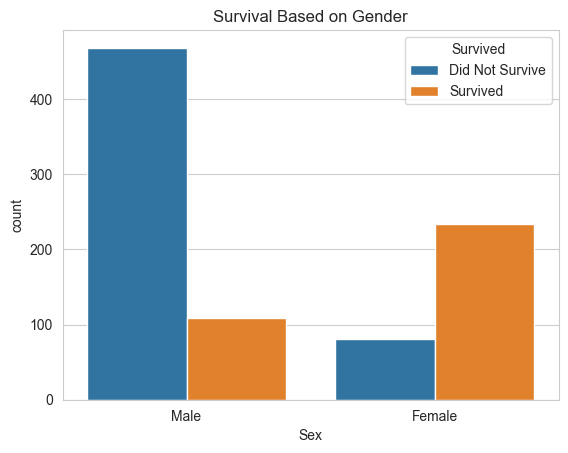

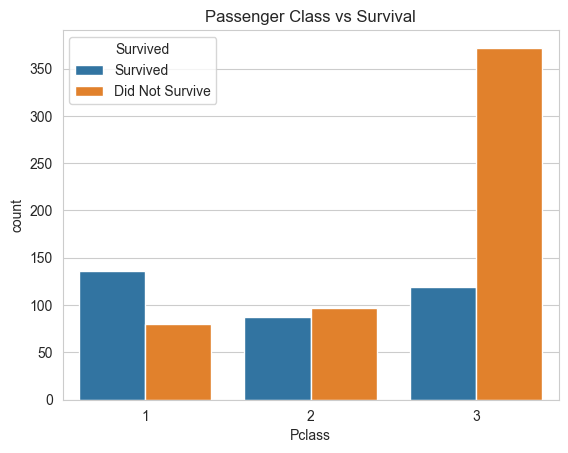

In [30]:
gender_labels = df.copy()

gender_labels['Sex'] = gender_labels['Sex'].map({
    0: 'Female',
    1: 'Male'
})

gender_labels['Survived'] = gender_labels['Survived'].map({
    0: 'Did Not Survive',
    1: 'Survived'
})

sns.countplot(x='Survived', data=gender_labels,palette={'Did Not Survive': 'steelblue', 'Survived': 'orange'})
plt.title("Survival Count")
plt.show()

sns.countplot(x='Sex', hue='Survived', data=gender_labels)
plt.title("Survival Based on Gender")
plt.show()

sns.countplot(x='Pclass', hue='Survived', data=gender_labels)
plt.title("Passenger Class vs Survival")
plt.show()